In [16]:
import os
import json
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# position distribution 디렉토리 내의 파일 탐색
file_path = "../data/binance/futures/um/monthly/position_distribution/1800000"
available_file_path = os.listdir(file_path)

n_samples = 0
for file in available_file_path:
    csv_path = os.path.join(file_path, file)
    df = pd.read_csv(csv_path, index_col=0)

    # JSON 형태로 저장된 리스트 컬럼 변환
    df["retail_long"] = df["retail_long"].apply(
        lambda x: json.loads(x) if isinstance(x, str) else x
    )
    df["retail_short"] = df["retail_short"].apply(
        lambda x: json.loads(x) if isinstance(x, str) else x
    )
    df["institutional_long"] = df["institutional_long"].apply(
        lambda x: json.loads(x) if isinstance(x, str) else x
    )
    df["institutional_short"] = df["institutional_short"].apply(
        lambda x: json.loads(x) if isinstance(x, str) else x
    )

    # 날짜/시간 열을 인덱스로 설정
    df.index = pd.to_datetime(df.index)

    # df 내부 데이터에서 nan이 하나라도 있는지 체크하고, 있다면, 파일명과 nan 갯수, nan이 해당하는 날짜 출력
    nan_count = df.isna().sum().sum()
    if nan_count > 0:
        print(f"파일명: {file}, NaN 개수: {nan_count}")
        print(df.loc[df.isna().any(axis=1)].index)

    n_samples += len(df) - nan_count

print(f"총 샘플 수: {n_samples}")

총 샘플 수: 48941


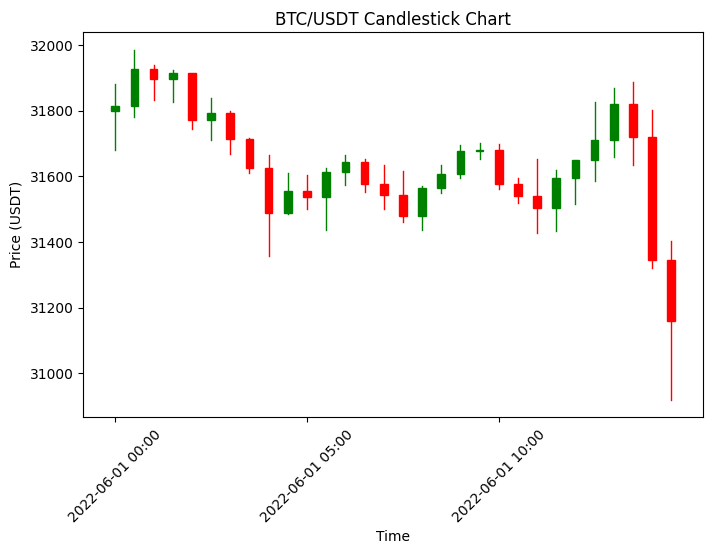

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# candle data 시각화
df = pd.read_csv(
    "/home/youngjins/project/belief_trading/data/binance/futures/um/monthly/klines/BTCUSDT/30m/BTCUSDT-30m-2022-06.csv",
    index_col=0,
)
df.index = pd.to_datetime(df.index, unit="ms")

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(1, 1, 1)

# 캔들 시각화
candles = df.iloc[:30, :]
# 캔들 차트 시각화
from matplotlib.patches import Rectangle

# 상승(양봉)과 하락(음봉) 구분
up = candles[candles.close >= candles.open]
down = candles[candles.close < candles.open]

# 봉 너비 설정
width = 0.4

# 양봉 그리기 (초록색 사각형)
for idx, row in up.iterrows():
    rect = Rectangle(
        xy=(candles.index.get_loc(idx) - width / 2, row["open"]),
        width=width,
        height=row["close"] - row["open"],
        facecolor="green",
        edgecolor="green",
        linewidth=1,
    )
    ax.add_patch(rect)
    # 위 꼬리 그리기
    ax.plot(
        [candles.index.get_loc(idx), candles.index.get_loc(idx)],
        [row["close"], row["high"]],
        color="green",
        linewidth=1,
    )
    # 아래 꼬리 그리기
    ax.plot(
        [candles.index.get_loc(idx), candles.index.get_loc(idx)],
        [row["open"], row["low"]],
        color="green",
        linewidth=1,
    )

# 음봉 그리기 (빨간색 사각형)
for idx, row in down.iterrows():
    rect = Rectangle(
        xy=(candles.index.get_loc(idx) - width / 2, row["close"]),
        width=width,
        height=row["open"] - row["close"],
        facecolor="red",
        edgecolor="red",
        linewidth=1,
    )
    ax.add_patch(rect)
    # 위 꼬리 그리기
    ax.plot(
        [candles.index.get_loc(idx), candles.index.get_loc(idx)],
        [row["open"], row["high"]],
        color="red",
        linewidth=1,
    )
    # 아래 꼬리 그리기
    ax.plot(
        [candles.index.get_loc(idx), candles.index.get_loc(idx)],
        [row["close"], row["low"]],
        color="red",
        linewidth=1,
    )

# x축 설정
ax.set_xticks(range(0, len(candles), 10))
ax.set_xticklabels(
    [candles.index[i].strftime("%Y-%m-%d %H:%M") for i in range(0, len(candles), 10)],
    rotation=45,
)
ax.set_title("BTC/USDT Candlestick Chart")
ax.set_xlabel("Time")
ax.set_ylabel("Price (USDT)")

plt.show()

BTCUSDT-pd-2022-09.csv


/tmp/ipykernel_8517/428372200.py:106: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=4.0)


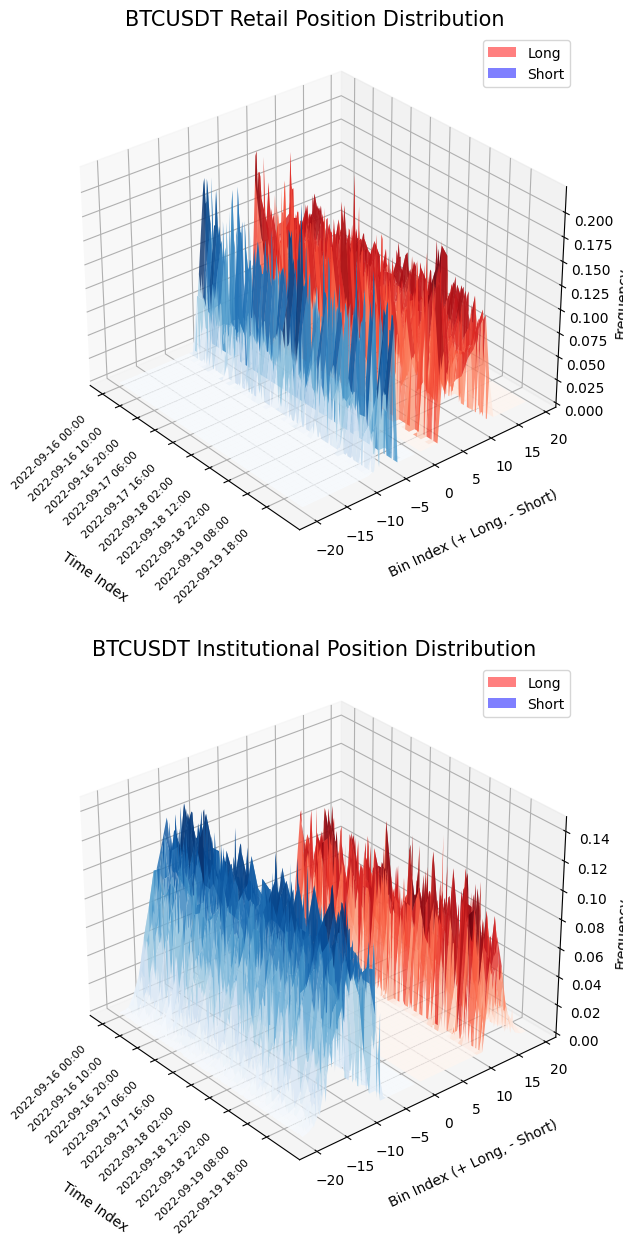

BTCUSDT-pd-2024-11.csv


/tmp/ipykernel_8517/428372200.py:106: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=4.0)


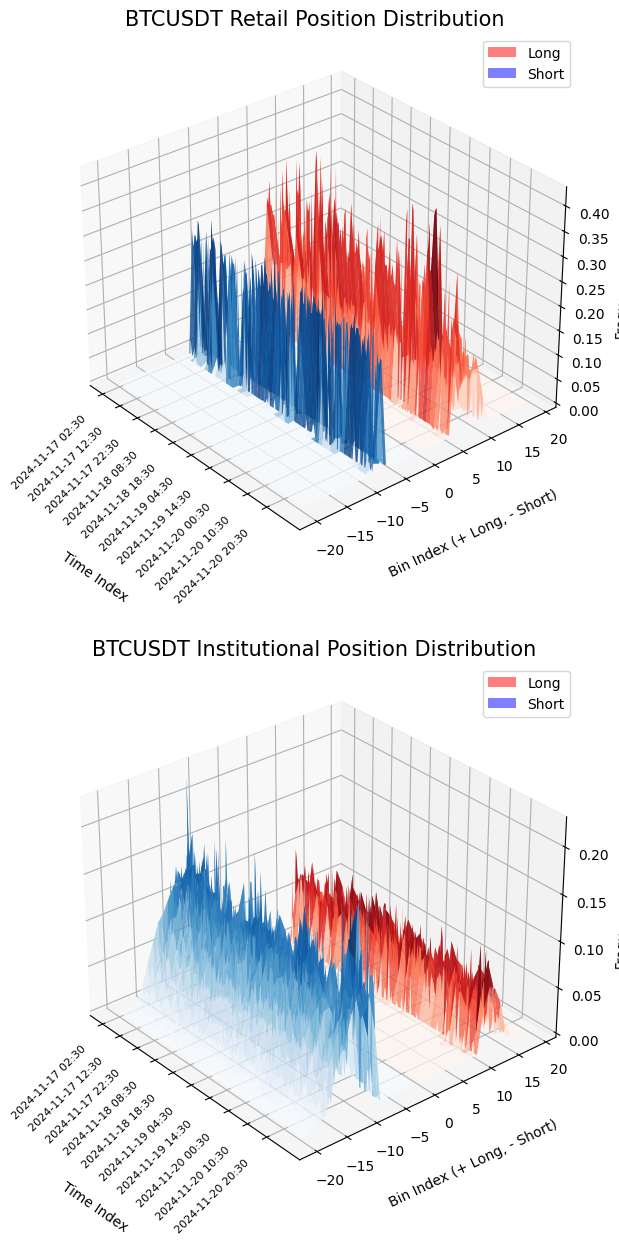

BTCUSDT-pd-2024-08.csv


/tmp/ipykernel_8517/428372200.py:106: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=4.0)


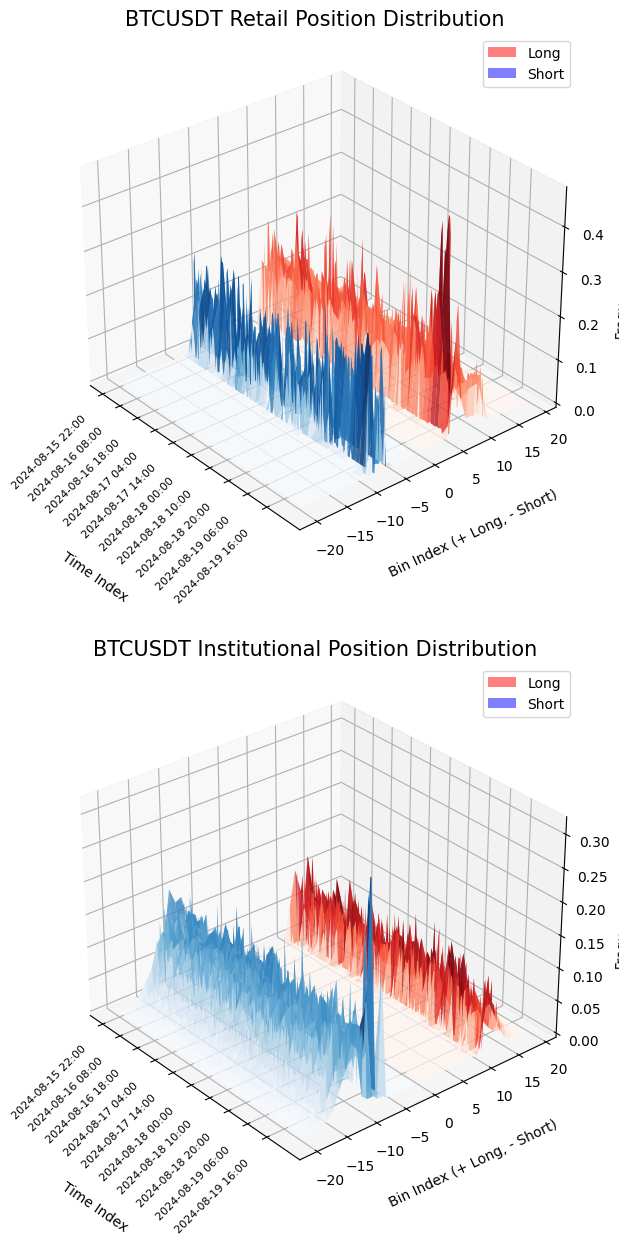

In [19]:
# position distribution 디렉토리 내의 파일 탐색
available_file_path = os.listdir(file_path)[:3]

for file in available_file_path:
    print(file)
    csv_path = os.path.join(file_path, file)
    df = pd.read_csv(csv_path, index_col=0)

    # JSON 형태로 저장된 리스트 컬럼 변환
    df["retail_long"] = df["retail_long"].apply(
        lambda x: json.loads(x) if isinstance(x, str) else x
    )
    df["retail_short"] = df["retail_short"].apply(
        lambda x: json.loads(x) if isinstance(x, str) else x
    )
    df["institutional_long"] = df["institutional_long"].apply(
        lambda x: json.loads(x) if isinstance(x, str) else x
    )
    df["institutional_short"] = df["institutional_short"].apply(
        lambda x: json.loads(x) if isinstance(x, str) else x
    )

    # 날짜/시간 열을 인덱스로 설정
    df.index = pd.to_datetime(df.index)

    # 임의의 시작 index로부터 순서대로 1000개 row 추출
    n_samples = 200
    start_idx = np.random.randint(0, len(df) - n_samples)
    data_to_plot = df.iloc[start_idx : start_idx + n_samples]

    # 그래프 생성
    fig = plt.figure(figsize=(24, 15))

    # 개인(retail)과 기관(institutional) 그래프 생성
    categories = ["retail", "institutional"]
    for idx, category in enumerate(categories):
        ax = fig.add_subplot(2, 1, idx + 1, projection="3d")

        # 데이터 준비
        x_times = np.arange(len(data_to_plot))

        # long과 short 데이터를 하나의 그래프에 표시하기 위해 bin 인덱스 조정
        long_bins = np.arange(len(data_to_plot.iloc[0][f"{category}_long"]))
        short_bins = (
            -np.arange(len(data_to_plot.iloc[0][f"{category}_short"]))[::-1] - 1
        )

        # Long 데이터 처리
        X_long, Y_long = np.meshgrid(x_times, long_bins)
        Z_long = np.zeros((len(long_bins), len(x_times)))
        for i, time_idx in enumerate(x_times):
            Z_long[:, i] = data_to_plot.iloc[i][f"{category}_long"]

        # Short 데이터 처리
        X_short, Y_short = np.meshgrid(x_times, short_bins)
        Z_short = np.zeros((len(short_bins), len(x_times)))
        for i, time_idx in enumerate(x_times):
            Z_short[:, i] = data_to_plot.iloc[i][f"{category}_short"]

        # 3D 표면 그래프 그리기
        surf_long = ax.plot_surface(
            X_long,
            Y_long,
            Z_long,
            cmap="Reds",
            edgecolor="none",
            alpha=0.8,
            label="Long",
        )
        surf_short = ax.plot_surface(
            X_short,
            Y_short,
            Z_short,
            cmap="Blues",
            edgecolor="none",
            alpha=0.8,
            label="Short",
        )

        # 그래프 제목 및 레이블 설정
        ax.set_title(
            f"BTCUSDT {category.capitalize()} Position Distribution", fontsize=15
        )
        ax.set_xlabel("Time Index", labelpad=50)
        ax.set_ylabel("Bin Index (+ Long, - Short)", labelpad=15)
        ax.set_zlabel("Frequency")

        # 실제 시간 표시를 위한 눈금 설정
        time_labels = [
            str(t)[:16] for t in data_to_plot.index
        ]  # 날짜와 시간(시:분)까지 표시
        tick_interval = max(1, len(x_times) // 10)
        selected_ticks = x_times[::tick_interval]
        selected_labels = [time_labels[i] for i in selected_ticks]
        ax.set_xticks(selected_ticks)
        ax.set_xticklabels(selected_labels, rotation=45, ha="right", fontsize=8)

        # x축 라벨이 더 잘 보이도록 뷰 각도 조정
        ax.view_init(elev=30, azim=-40)

        # 범례 추가
        long_proxy = plt.Rectangle((0, 0), 1, 1, fc="red", alpha=0.5)
        short_proxy = plt.Rectangle((0, 0), 1, 1, fc="blue", alpha=0.5)
        ax.legend([long_proxy, short_proxy], ["Long", "Short"], loc="upper right")

    plt.tight_layout(pad=4.0)
    plt.show()

BTCUSDT-pd-2022-09.csv


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


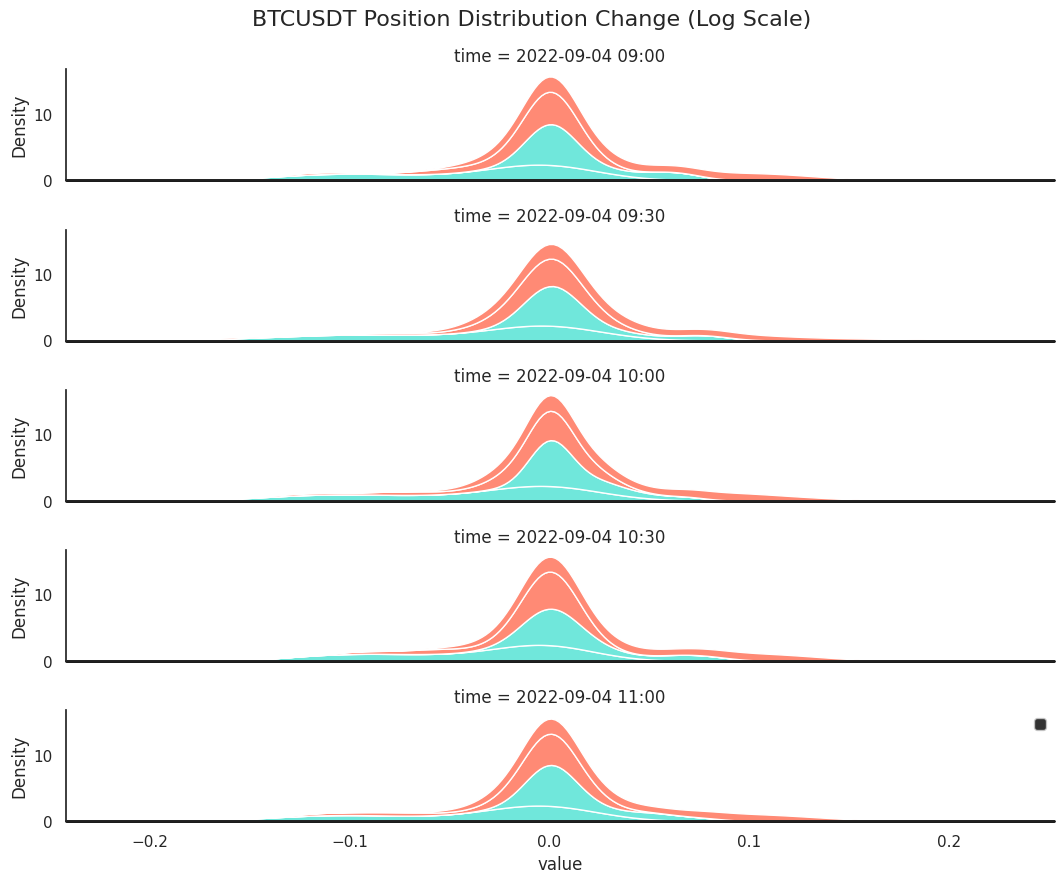

BTCUSDT-pd-2024-11.csv


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


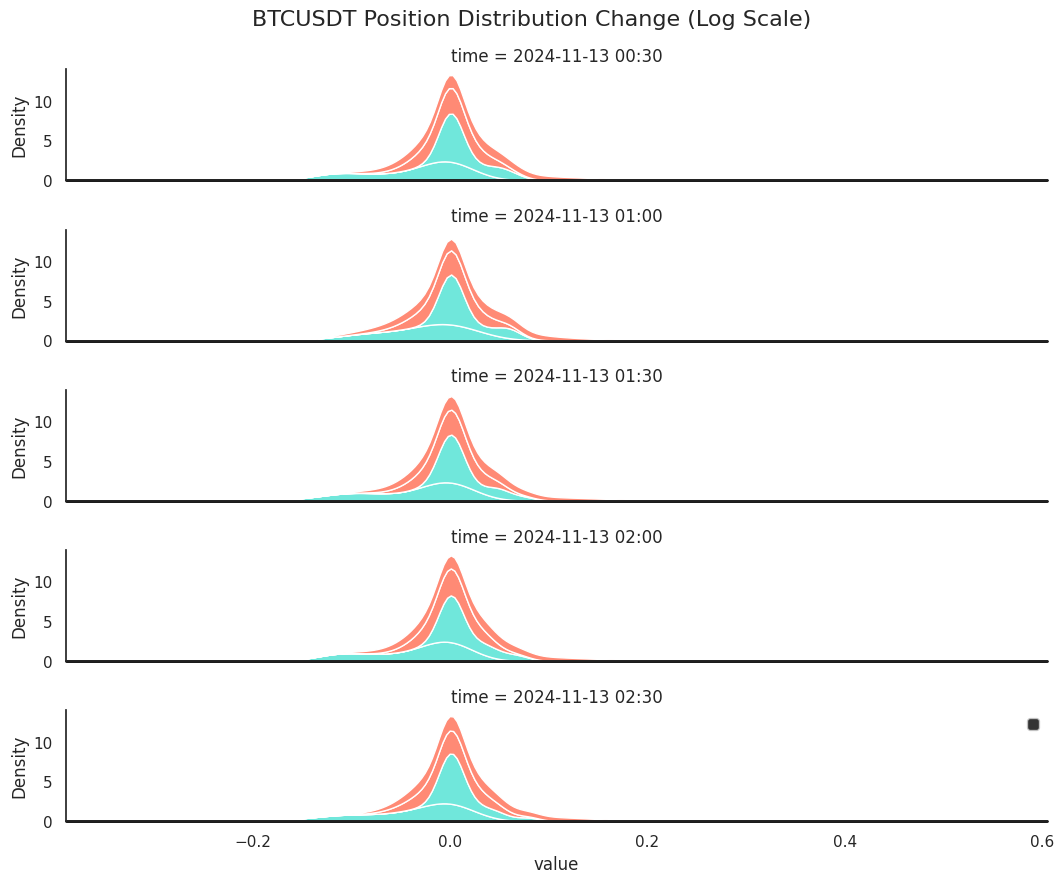

BTCUSDT-pd-2024-08.csv


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


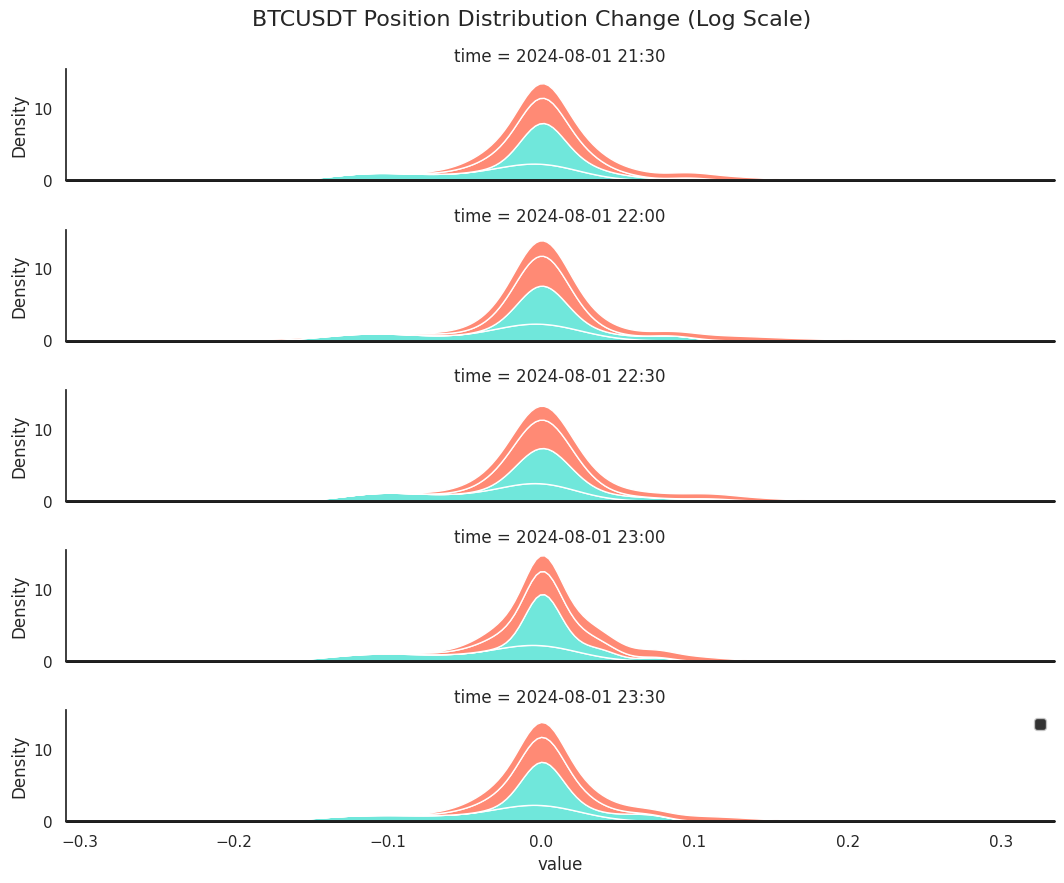

In [40]:
import seaborn as sns
from sklearn.mixture import GaussianMixture

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# position distribution 디렉토리 내의 파일 탐색
available_file_path = os.listdir(file_path)[:3]

for file in available_file_path:
    print(file)
    df = pd.read_csv(os.path.join(file_path, file), index_col=0)

    # 날짜/시간 열을 인덱스로 설정
    df.index = pd.to_datetime(df.index)

    # JSON 형태로 저장된 리스트 컬럼 변환
    df["retail_long"] = df["retail_long"].apply(
        lambda x: json.loads(x) if isinstance(x, str) else x
    )
    df["retail_short"] = df["retail_short"].apply(
        lambda x: json.loads(x) if isinstance(x, str) else x
    )
    df["institutional_long"] = df["institutional_long"].apply(
        lambda x: json.loads(x) if isinstance(x, str) else x
    )
    df["institutional_short"] = df["institutional_short"].apply(
        lambda x: json.loads(x) if isinstance(x, str) else x
    )

    # 임의의 시작 index로부터 순서대로 1000개 row 추출
    n_samples = 5
    start_idx = np.random.randint(0, len(df) - n_samples)
    data_to_plot = df.iloc[start_idx : start_idx + n_samples]

    # 리지 플롯을 위한 데이터 준비
    plot_data = []

    # 각 시간별로 데이터 처리
    for idx, row in data_to_plot.iterrows():
        time_str = idx.strftime("%Y-%m-%d %H:%M")

        # 개인 투자자 데이터 (long, short 분리)
        for value in row["retail_long"]:
            plot_data.append({"time": time_str, "value": value, "type": "retail_long"})

        for value in row["retail_short"]:
            plot_data.append(
                {"time": time_str, "value": -value, "type": "retail_short"}
            )  # short은 음수로 변환

        # 기관 투자자 데이터 (long, short 분리)
        for value in row["institutional_long"]:
            plot_data.append(
                {"time": time_str, "value": value, "type": "institutional_long"}
            )

        for value in row["institutional_short"]:
            plot_data.append(
                {"time": time_str, "value": -value, "type": "institutional_short"}
            )  # short은 음수로 변환

    # 데이터프레임 생성
    plot_df = pd.DataFrame(plot_data)

    # 리지 플롯 생성
    g = sns.FacetGrid(data=plot_df, row="time", aspect=6, height=1.8)

    # 색상 매핑 설정 - retail은 tomato, institutional은 turquoise 계열로 통일
    color_map = {
        "retail_long": "tomato",
        "retail_short": "tomato",
        "institutional_long": "turquoise",
        "institutional_short": "turquoise",
    }

    # 밀도 그래프 그리기 (x축 로그 스케일 적용)
    g.map_dataframe(
        sns.kdeplot,
        "value",
        bw_adjust=1,
        hue="type",
        hue_order=[
            "retail_long",
            "retail_short",
            "institutional_long",
            "institutional_short",
        ],
        palette=color_map,
        multiple="stack",
    )

    g.map(plt.axhline, y=0, lw=2, clip_on=False, color="black")

    # 제목 및 레이블 설정
    plt.suptitle(f"BTCUSDT Position Distribution Change (Log Scale)", fontsize=16)
    plt.tight_layout()
    plt.legend(loc="upper right")
    # plt.subplots_adjust(top=0.95)
    plt.show()